In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\messed_patient_health_records_1500_rows.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1500 non-null   int64  
 1   age             1232 non-null   float64
 2   gender          1184 non-null   object 
 3   region          1262 non-null   object 
 4   bmi             1496 non-null   float64
 5   blood_pressure  1497 non-null   float64
 6   cholesterol     1498 non-null   float64
 7   glucose         1499 non-null   float64
 8   disease_risk    1500 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 105.6+ KB


In [27]:
df.isnull().sum()

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
bmi_missing       0
dtype: int64

# Missing value


# task 1 

In [16]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy="mean")

df["bmi"] = mean_imputer.fit_transform(df[["bmi"]])





In [20]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="most_frequent")

df["region"] = cat_imputer.fit_transform(df[["region"]]).ravel()



In [22]:
gender_mode = df["gender"].mode()[0]
df["gender"].fillna(gender_mode, inplace=True)


In [25]:
df["bmi_missing"] = df["bmi"].isnull().astype(int)

random_sample = df["bmi"].dropna().sample(
    df["bmi"].isnull().sum(),
    random_state=1
)

random_sample.index = df[df["bmi"].isnull()].index
df.loc[df["bmi"].isnull(), "bmi"] = random_sample



In [26]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = knn_imputer.fit_transform(df[num_cols])


# task 2 outliers

In [28]:
from scipy import stats
import numpy as np

df_z = df.copy()

# Calculate Z-score
z_scores = np.abs(stats.zscore(df_z[["cholesterol", "glucose"]]))

# Keep rows where Z < 3
df_z = df_z[(z_scores < 3).all(axis=1)]

print("Shape after Z-score removal:", df_z.shape)


Shape after Z-score removal: (1497, 10)


In [29]:
df_iqr = df.copy()

Q1 = df_iqr["bmi"].quantile(0.25)
Q3 = df_iqr["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df_iqr[(df_iqr["bmi"] >= lower) & (df_iqr["bmi"] <= upper)]

print("Shape after IQR removal:", df_iqr.shape)


Shape after IQR removal: (1500, 10)


In [30]:
df_percentile = df.copy()

for col in ["bmi", "blood_pressure", "cholesterol", "glucose"]:
    lower = df_percentile[col].quantile(0.01)
    upper = df_percentile[col].quantile(0.99)
    
    df_percentile = df_percentile[
        (df_percentile[col] >= lower) &
        (df_percentile[col] <= upper)
    ]

print("Shape after Percentile removal:", df_percentile.shape)


Shape after Percentile removal: (1415, 10)


In [31]:
df_winsor = df.copy()

for col in ["bmi", "blood_pressure", "cholesterol", "glucose"]:
    lower = df_winsor[col].quantile(0.01)
    upper = df_winsor[col].quantile(0.99)
    
    df_winsor[col] = np.where(df_winsor[col] < lower, lower, df_winsor[col])
    df_winsor[col] = np.where(df_winsor[col] > upper, upper, df_winsor[col])

print("Winsorization Done")
print("Shape after Winsorization:", df_winsor.shape)


Winsorization Done
Shape after Winsorization: (1500, 10)


In [32]:
print("Original Shape:", df.shape)
print("Z-score Shape:", df_z.shape)
print("IQR Shape:", df_iqr.shape)
print("Percentile Shape:", df_percentile.shape)
print("Winsor Shape:", df_winsor.shape)


Original Shape: (1500, 10)
Z-score Shape: (1497, 10)
IQR Shape: (1500, 10)
Percentile Shape: (1415, 10)
Winsor Shape: (1500, 10)


# Task 2 Final clean dataset

In [33]:
from scipy import stats

z = np.abs(stats.zscore(df[["cholesterol", "glucose"]]))
df = df[(z < 3).all(axis=1)]


In [34]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["bmi"] >= lower) & (df["bmi"] <= upper)]


In [35]:
for col in ["blood_pressure"]:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


# final check

In [36]:
print("Final Shape:", df.shape)
print(df.describe())


Final Shape: (1497, 10)
         patient_id          age          bmi  blood_pressure  cholesterol  \
count   1497.000000  1497.000000  1497.000000     1497.000000  1497.000000   
mean   10750.118904    46.526386    28.317168      130.635404   240.586907   
std      433.154360    24.869139     9.575392       35.602492    68.477579   
min    10001.000000     1.000000    12.000000       71.000000    80.000000   
25%    10375.000000    27.000000    20.100000       98.000000   181.000000   
50%    10750.000000    47.000000    28.100000      133.000000   244.000000   
75%    11125.000000    63.000000    36.200000      162.000000   302.000000   
max    11500.000000    94.000000    60.000000      188.000000   349.000000   

           glucose  disease_risk  bmi_missing  
count  1497.000000   1497.000000       1497.0  
mean    173.570875      0.496994          0.0  
std      60.113610      0.500158          0.0  
min      30.000000      0.000000          0.0  
25%     122.000000      0.000000 

# breif report

In this project, I handled missing values using median imputation for numerical columns like age and BMI because it is less affected by extreme values, and mode imputation for categorical columns like gender and region since replacing with the most common category is practical. For outliers, I used methods like Z-score, IQR, and winsorization, and I found that winsorization preserved data quality better because it reduced the impact of extreme values without removing too many records. Overall, data cleaning improved the dataset by making it more consistent, reliable, and suitable for further analysis and modeling.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==============================
# 1️⃣ LOAD ORIGINAL DATA
# ==============================

df_before = pd.read_csv("messed_patient_health_records_1500_rows.csv")

# Make a copy for cleaning
df_after = df_before.copy()


In [43]:
# ==============================
# 2️⃣ HANDLE MISSING VALUES
# ==============================

# Numerical
df_after["age"].fillna(df_after["age"].median(), inplace=True)
df_after["bmi"].fillna(df_after["bmi"].median(), inplace=True)

# Categorical
df_after["gender"].fillna(df_after["gender"].mode()[0], inplace=True)
df_after["region"].fillna(df_after["region"].mode()[0], inplace=True)

In [44]:
# ==============================
# 2️⃣ HANDLE MISSING VALUES
# ==============================

# Numerical
df_after["age"].fillna(df_after["age"].median(), inplace=True)
df_after["bmi"].fillna(df_after["bmi"].median(), inplace=True)

# Categorical
df_after["gender"].fillna(df_after["gender"].mode()[0], inplace=True)
df_after["region"].fillna(df_after["region"].mode()[0], inplace=True)

# ==============================
# 3️⃣ HANDLE OUTLIERS
# ==============================

# 🔹 Z-score for cholesterol & glucose
z = np.abs(stats.zscore(df_after[["cholesterol", "glucose"]]))
df_after = df_after[(z < 3).all(axis=1)]

# 🔹 IQR for BMI
Q1 = df_after["bmi"].quantile(0.25)
Q3 = df_after["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_after = df_after[(df_after["bmi"] >= lower) & (df_after["bmi"] <= upper)]

# 🔹 Winsorization for blood pressure
lower_bp = df_after["blood_pressure"].quantile(0.01)
upper_bp = df_after["blood_pressure"].quantile(0.99)

df_after["blood_pressure"] = np.where(
    df_after["blood_pressure"] < lower_bp,
    lower_bp,
    df_after["blood_pressure"]
)

df_after["blood_pressure"] = np.where(
    df_after["blood_pressure"] > upper_bp,
    upper_bp,
    df_after["blood_pressure"]
)

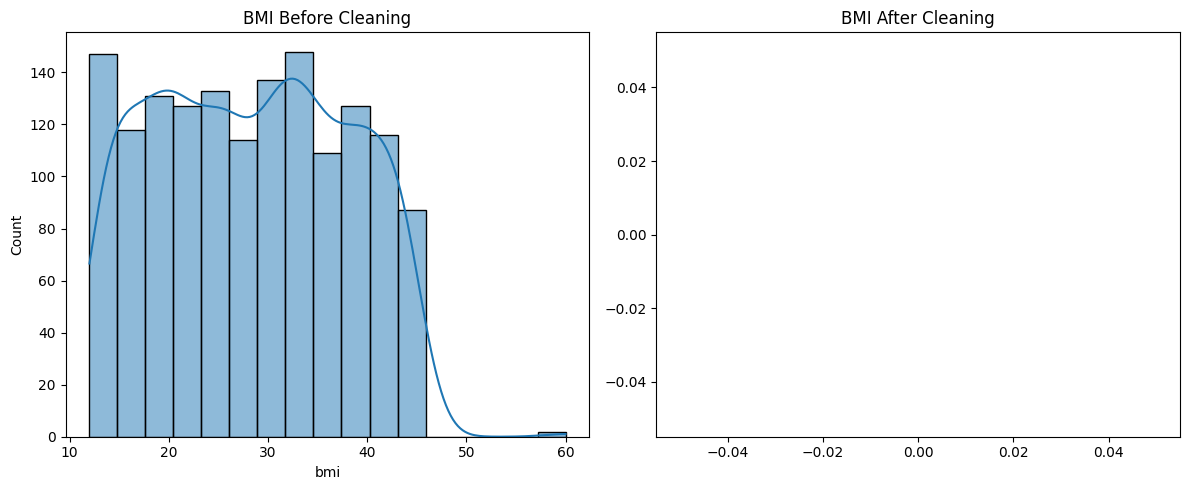

In [45]:
# ==============================
# 5️⃣ BEFORE vs AFTER GRAPHS
# ==============================

# -------- BMI Histogram --------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_before["bmi"], kde=True)
plt.title("BMI Before Cleaning")

plt.subplot(1,2,2)
sns.histplot(df_after["bmi"], kde=True)
plt.title("BMI After Cleaning")

plt.tight_layout()
plt.show()

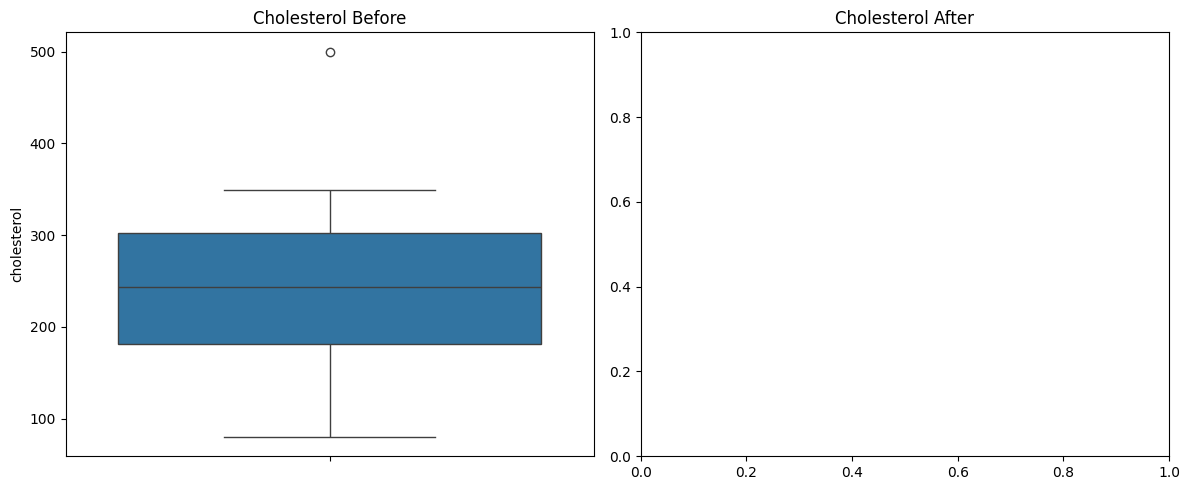

In [46]:

# -------- Cholesterol Boxplot --------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df_before["cholesterol"])
plt.title("Cholesterol Before")

plt.subplot(1,2,2)
sns.boxplot(y=df_after["cholesterol"])
plt.title("Cholesterol After")

plt.tight_layout()
plt.show()

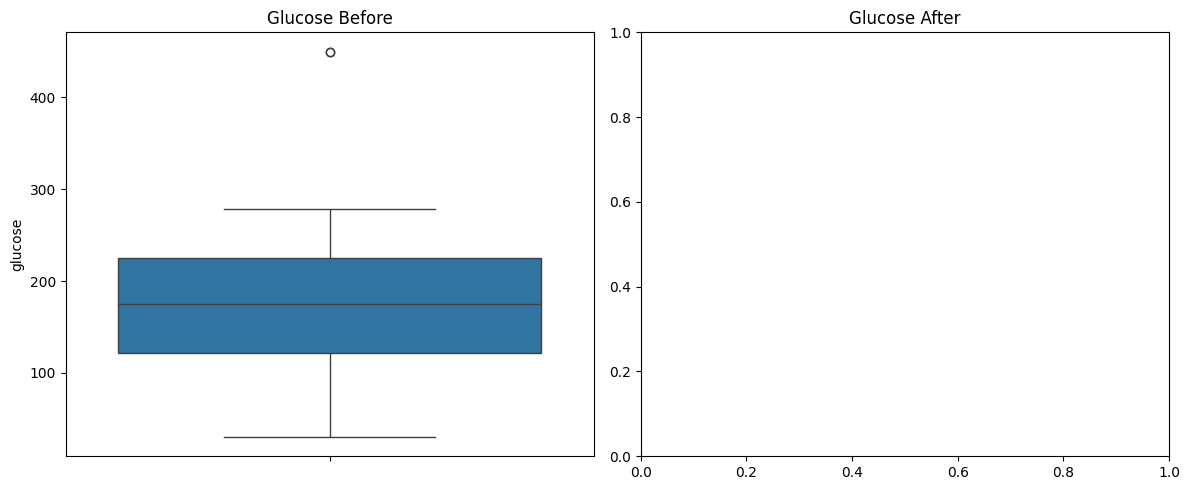

In [47]:
# -------- Glucose Boxplot --------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df_before["glucose"])
plt.title("Glucose Before")

plt.subplot(1,2,2)
sns.boxplot(y=df_after["glucose"])
plt.title("Glucose After")

plt.tight_layout()
plt.show()

s